In [1]:
import os
import tarfile
import urllib
import numpy as np

In [2]:
DOWNLOAD_ROOT= "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH=os.path.join("datasets","housing")
HOUSING_URL=DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

In [3]:
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url,tgz_path)
    housing_tgz=tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()
    

In [4]:
#fetch_housing_data()

In [5]:
import pandas as pd


In [6]:
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path=os.path.join(housing_path,"housing.csv")
    return pd.read_csv(csv_path)

In [7]:
housing=load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
housing.info() # the .info gives a summary of datasets

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


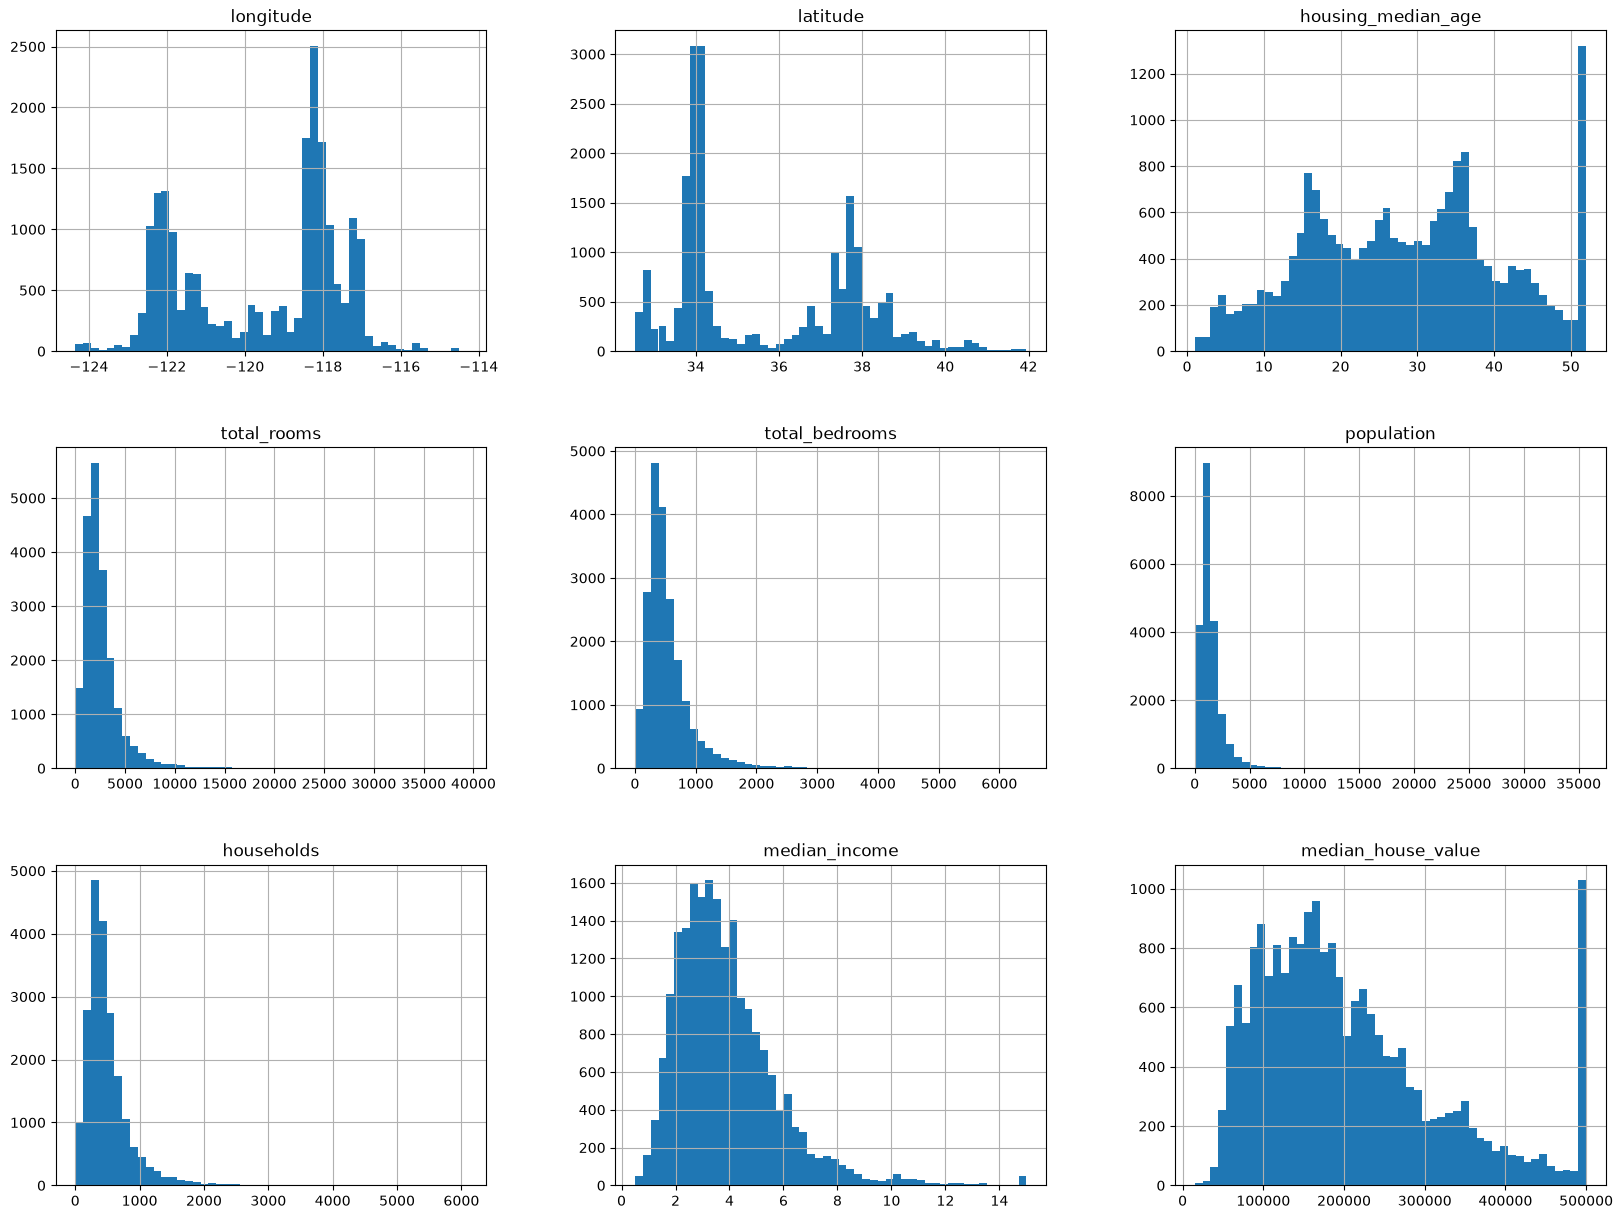

In [9]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [10]:
'''from zlib import crc32
def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32'''

'from zlib import crc32\ndef test_set_check(identifier, test_ratio):\n    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32'

In [11]:
'''def split_train_test_by_id(data,test_ratio,id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_:test_set_check(id_,test_ratio))
    return data.loc[~in_test_set],data.loc[in_test_set]'''

'def split_train_test_by_id(data,test_ratio,id_column):\n    ids = data[id_column]\n    in_test_set = ids.apply(lambda id_:test_set_check(id_,test_ratio))\n    return data.loc[~in_test_set],data.loc[in_test_set]'

In [12]:
# spliting the dataset into test and train 
'''
def split_train_test(data,test_ratio):
   #np.random.seed(42)
    shuffled_indices=np.random.permutation(len(data))
    test_set_size= int(len(data)*test_ratio)
    test_indices=shuffled_indices[:test_set_size]
    train_indices=shuffled_indices[test_set_size:]
    return data.iloc[train_indices],data.iloc[test_indices] '''

'\ndef split_train_test(data,test_ratio):\n   #np.random.seed(42)\n    shuffled_indices=np.random.permutation(len(data))\n    test_set_size= int(len(data)*test_ratio)\n    test_indices=shuffled_indices[:test_set_size]\n    train_indices=shuffled_indices[test_set_size:]\n    return data.iloc[train_indices],data.iloc[test_indices] '

it seems fine but there is a issue with this kind of spiliting , that is that every time this function get executed it will generate ramdom samples for the test and train set and eventually after the multiple executions the model will get familiar to the entire data and it will cause the spooning bias 

so to fix that we can put np.random.seed(42) , but it'll again brick it next time you pick a updated dataset(online learning).


# To maintain a consistent train/test split when updating a dataset, you can use a mathematical hash of each instance's unique identifier
# . By assigning an instance to the test set only if its hash value falls below a specific threshold (such as 20% of the maximum value), you ensure that historical data always remains in its original set
#  This method guarantees that any newly added data is proportionally split (allocating 20% of new instances to the test set) without ever accidentally leaking previous training instances into your new test set

but since our data here does not have any unique identifier we will have to reset_index()


In [13]:
#housing_with_id=housing.reset_index()
#train_data, test_data=split_train_test_by_id(housing_with_id,0.2,"index")

yeh upari wali sab sarri jo humne technique lagane ki kosis kari thi vo sklearn. model_selection ka train_test_split() fun kr deta hai but with some extra features , vo hum baad me dekhenge


In [14]:
from sklearn.model_selection import train_test_split
train_set,test_set=train_test_split(housing, test_size=0.2,random_state=42)

In [15]:
housing['income_cat']=pd.cut(housing['median_income'],
                             bins=[0.,1.5,3.0,4.5,6.,np.inf],
                             labels=[1,2,3,4,5])

<Axes: >

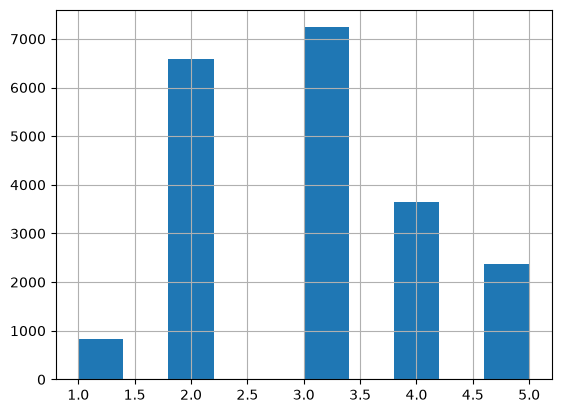

In [16]:
housing['income_cat'].hist()

In [17]:
from sklearn.model_selection import StratifiedShuffleSplit

In [18]:
sss=StratifiedShuffleSplit(random_state=42,test_size=0.2,n_splits=1)

In [19]:
for test_index,train_index in sss.split(housing,housing['income_cat']):
    strat_test_set=housing.loc[test_index]
    strat_train_set=housing.loc[train_index]

In [20]:
strat_test_set['income_cat'].value_counts()/len(strat_test_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

In [21]:
for set_ in(strat_test_set,strat_train_set):
    set_.drop('income_cat',axis=1,inplace=True)

In [22]:
housing.sample(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
3853,-118.45,34.18,33.0,2077.0,486.0,1021.0,450.0,3.6019,225000.0,<1H OCEAN,3
18994,-121.95,38.43,19.0,3011.0,551.0,1665.0,535.0,5.1534,232800.0,INLAND,4
141,-122.21,37.82,52.0,2375.0,333.0,813.0,350.0,7.0549,331400.0,NEAR BAY,5
7713,-118.15,33.95,31.0,1053.0,230.0,686.0,211.0,4.0000,263200.0,<1H OCEAN,3
13482,-117.35,34.12,22.0,5640.0,889.0,3157.0,887.0,4.1581,126500.0,INLAND,3
11702,-117.97,33.89,15.0,3801.0,542.0,1992.0,526.0,9.0683,367400.0,<1H OCEAN,5
6449,-118.04,34.12,39.0,2522.0,380.0,1113.0,357.0,5.2249,445200.0,INLAND,4
9148,-118.48,34.47,36.0,84.0,12.0,29.0,17.0,3.3750,187500.0,<1H OCEAN,3
18096,-122.04,37.33,26.0,2690.0,401.0,1264.0,429.0,7.7643,474700.0,<1H OCEAN,5
8241,-118.19,33.77,31.0,1711.0,691.0,1092.0,568.0,1.0714,150000.0,NEAR OCEAN,1


## visualisation of the data


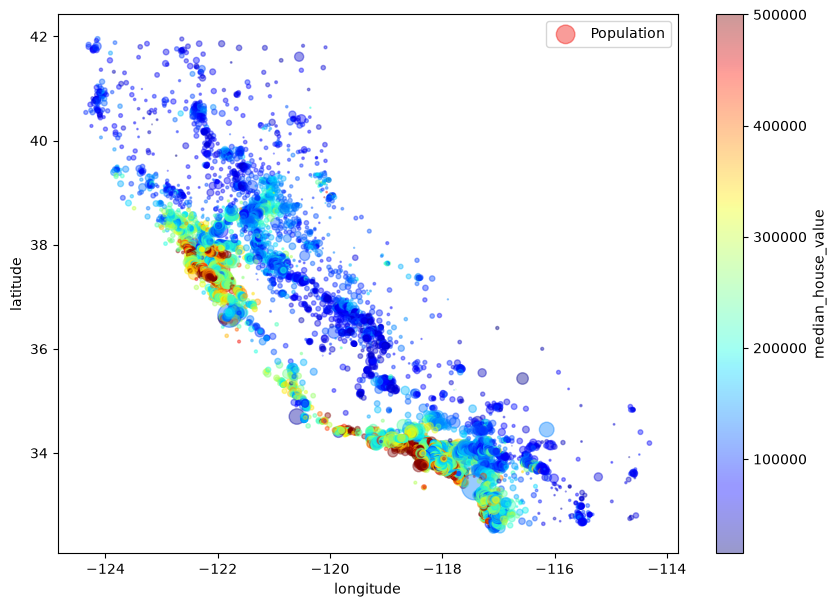

In [23]:
housing.plot(kind='scatter',
             x='longitude',
             y='latitude',
             alpha=0.4,
             s=housing['population']/100,
             label="Population",
             figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"),
             colorbar=True
            )
plt.legend()

## looking for correlation     

In [24]:
proximity_mapping={'INLAND':0,
         '<1H OCEAN':1,
        'NEAR BAY':2,
         'NEAR OCEAN':3, 
         'ISLAND': 4
        }
housing_orignal=housing.copy()
housing_orignal['ocean_proximity_code']=housing['ocean_proximity'].map(proximity_mapping)
corr_matrix=housing_orignal.corr(method='pearson',numeric_only=True)

In [25]:

corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value      1.000000
median_income           0.688075
ocean_proximity_code    0.383244
total_rooms             0.134153
housing_median_age      0.105623
households              0.065843
total_bedrooms          0.049686
population             -0.024650
longitude              -0.045967
latitude               -0.144160
Name: median_house_value, dtype: float64

# Another way is to do this is through pandas scatter matrix function which plots every attr against every attr

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

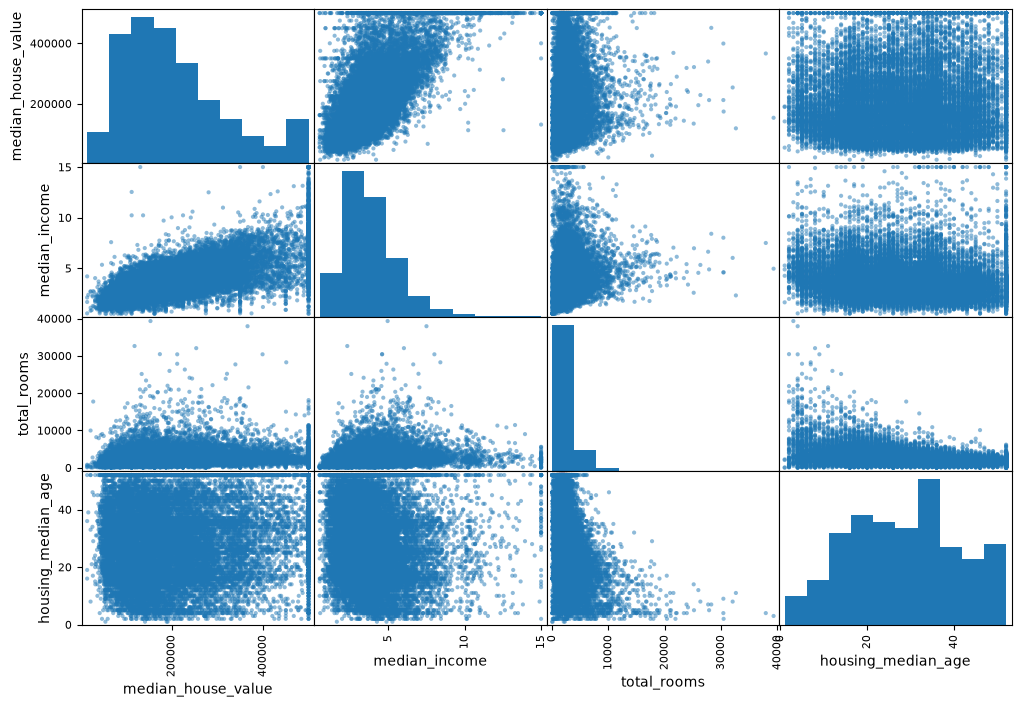

In [26]:
from pandas.plotting import scatter_matrix
attr=['median_house_value','median_income','total_rooms','housing_median_age']
scatter_matrix(housing[attr],figsize=(12,8))

<Axes: xlabel='median_house_value', ylabel='median_income'>

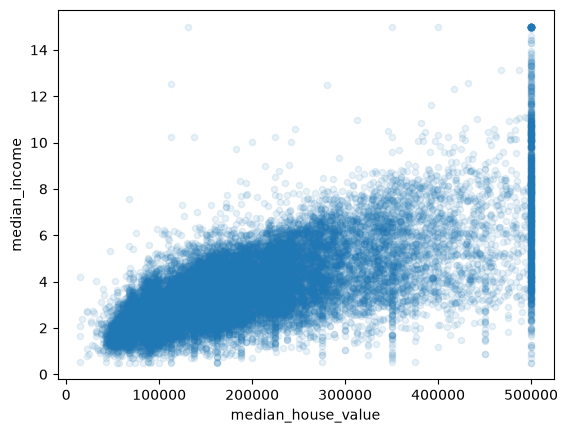

In [27]:
housing.plot(kind='scatter',x='median_house_value',y='median_income',alpha=0.1)

In [28]:
housing=strat_train_set.drop('median_house_value',axis=1)
housing_labels=strat_train_set['median_house_value'].copy()

In [29]:
median=housing['total_bedrooms'].median()
housing.fillna({'total_bedrooms':median},inplace=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816,<1H OCEAN
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099,<1H OCEAN
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839,<1H OCEAN
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,<1H OCEAN
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...
12182,-117.29,33.72,19.0,2248.0,427.0,1207.0,368.0,2.8170,<1H OCEAN
7275,-118.24,33.99,33.0,885.0,294.0,1270.0,282.0,2.1615,<1H OCEAN
17223,-119.72,34.44,43.0,1781.0,342.0,663.0,358.0,4.7000,<1H OCEAN
10786,-117.91,33.63,30.0,2071.0,412.0,1081.0,412.0,4.9125,<1H OCEAN


# this above funtion can be also applied from the skleran library trhouthe impute module

from sklear.impute import SimpleImputer
imputer=SimpleImputer(strategy='median')

# note : the imputer fitting only works on the numerical data to make sure to remove/drop the non numric attr before imputer.fit(df)


In [30]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='median')

In [31]:
housing_num=housing.drop('ocean_proximity',axis=1)
imputer.fit(housing_num)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['longitude','latitude','housing_median_age',...,'population','households', 'median_income']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](8,)","[-118.46, 34.22, 28. ,...,1172.5 , 416. , 3.51]"


In [32]:
X=imputer.transform(housing_num)

In [33]:
housing_tr=pd.DataFrame(X,columns=housing_num.columns, index=housing_num.index)

In [34]:
housing_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529
...,...,...,...,...,...,...,...,...
12182,-117.29,33.72,19.0,2248.0,427.0,1207.0,368.0,2.8170
7275,-118.24,33.99,33.0,885.0,294.0,1270.0,282.0,2.1615
17223,-119.72,34.44,43.0,1781.0,342.0,663.0,358.0,4.7000
10786,-117.91,33.63,30.0,2071.0,412.0,1081.0,412.0,4.9125


In [35]:
housing_cat=housing[['ocean_proximity']]
housing_cat.head(10)

,ocean_proximity
5241,<1H OCEAN
17352,<1H OCEAN
3505,<1H OCEAN
7777,<1H OCEAN
14155,NEAR OCEAN
7057,<1H OCEAN
33,NEAR BAY
17049,NEAR OCEAN
18164,<1H OCEAN
10444,NEAR OCEAN


In [36]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder=OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

array([[0.],
       [0.],
       [0.],
       [0.],
       [4.],
       [0.],
       [3.],
       [4.],
       [0.],
       [4.]])

In [37]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

# here the encoding done is 0-4 however 0 and 4 are much closer related to each other than the category 0 and one 1. so to fix this we use one hot code ecoding so what one hot coding does is that it make n different columns for n different categories and then matches the row and column where the categorie is same and puts one in that column

 the one hote

In [38]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder1hot=OneHotEncoder()
housing_cat_1hot=cat_encoder1hot.fit_transform(housing_cat)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4128 stored elements and shape (4128, 5)>

In [39]:
housing_cat_1hot.toarray()

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.]], shape=(4128, 5))

# coustom transformers


In [40]:
from sklearn.base import BaseEstimator,TransformerMixin
rooms_ix,bedrooms_ix,population_ix, households_ix= 3,4,5,6


In [41]:
class CombinedAttri(BaseEstimator,TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room= add_bedrooms_per_room
        
    def fit(self,X,y=None):
        return self
        
    def transform(self, add_bedrooms_per_room,):
        room_per_household=X[:,rooms_ix]/X[:,households_ix]
        population_per_household=X[:,population_ix]/X[:,households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_rooms=X[:,bedrooms_ix]/X[:,rooms_ix]
            return  np.c_[X,room_per_household,population_per_household,bedrooms_per_rooms]
        else :
            return np.c_[X,room_per_household,population_per_household]
    


In [42]:
attr_adder=CombinedAttri(add_bedrooms_per_room=False)
houseing_extra_attri=attr_adder.transform(housing.values)

## pipelines in sklean
if we have to apply multiple transformations in on a single dataset and output of one is the input parameter for another then the sklearn library provides a usefull lib , 

# from sklearn.pipeline import Pipeline

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [44]:
num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('attri',CombinedAttri()),
    ('stand',StandardScaler())
])

In [45]:
housing_num_tr=num_pipeline.fit_transform(housing_num)

## the sklearn also provided the library to transforms all the columnns at the same time
this is done by column transformers


In [46]:
from sklearn.compose import ColumnTransformer

In [47]:
num_attri= list(housing_num)
cat_attri= ["ocean_proximity"]
full_pipeline=ColumnTransformer([
    ("num",num_pipeline,num_attri),
    ("cat", OneHotEncoder(),cat_attri),
])

In [48]:
housing_prepared = full_pipeline.fit_transform(housing)

## note : 
when doing columnTransformer 
first we give the transformation for teh numerical columns names then list of 
categorial columns name


In [49]:
from sklearn.linear_model import LinearRegression
lin_reg= LinearRegression()
lin_reg.fit(housing_prepared,housing_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[-54664.4 ,-55209.44, 12009.6 ,...,141420.33,-29485.03,-19443.97]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.446e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,15
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[126.92, 94.24, 90.35,..., 7.55, 1.93, 0. ]"


## now we have a working LR model for our prepared dataset
now using the model.pridict we can get the feature output for the 
given data set if we want to have lable for any of the n house princinig 


In [50]:
 from sklearn.metrics import mean_squared_error

In [52]:
housing_prediction= lin_reg.predict(housing_prepared)
lin_mse=mean_squared_error(housing_labels,housing_prediction)
lin_rmse=np.sqrt(lin_mse)
lin_rmse

np.float64(66787.70814784677)

### Decision Tree Regressor

In [53]:
from sklearn.tree import DecisionTreeRegressor

In [54]:
tree_reg=DecisionTreeRegressor()
tree_reg.fit(housing_prepared,housing_labels)


,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [56]:
housing_predictions=tree_reg.predict(housing_prepared)

In [58]:
tree_mse=mean_squared_error(housing_labels,housing_predictions)
tree_rmse=np.sqrt(tree_mse)

In [59]:
tree_rmse

np.float64(0.0)

wait what how could it be so perfect that it is producing zero error
is this model really perfect now

no, it more that the model has overfit the data. 
as we know that it is not good to touch the test set until you are ready to lauch 
the moodel you are confident about . so you need part of the training set to tain and  a part of it for validation of the model

so a solution could be splitting the dataset using train_test_split() on the training 
set again and breaking the data into much smaller portion for validation set from the 
trainning set 
    
it would n't be that difficult 

But great alternative would be scikit-learns
### k-fold cross validation
it is called k fold because it breaks the data into k distinct subsets 
called folds
 # then it trains and evaluate the Descision tree model k times , picking different fold for 
# evaluation every time and training on other k-1 folds.

In [60]:
from sklearn.model_selection import cross_val_score

In [ ]:
scores= cross_val_score(tree_reg, housing_prepared,housing_labels
                       ,scoring="neg_mean_squared_error",cv=10)
tree_rmse_scores= np.sqrt(scores)